# Multi-Class Classification

In this notebook we will learn about multi-class classificatio using multiple logistic regression.

### **Review:Binary classification with Logistic Regression**


**Binary classification** is the simplest type of classification where we predict one of exactly **two possible outcomes**.

### Examples of Binary Classification:

| Problem | Class 0 (Negative) | Class 1 (Positive) |
|---|---|---|
| Email filtering | Not spam | Spam |
| Disease detection | No disease | Has disease |
| Loan approval | Won't default | Will default |
| Tumor diagnosis | Benign | Malignant |
| Fraud detection | Legitimate | Fraudulent |
| Customer churn | Stay | Leave |



In binary classification:
- We have only **2 classes** to predict
- Each prediction is either **Correct** or **Incorrect**
- We can represent predictions as **0 or 1** (False or True)

### The Decision Boundary:

Most binary classifiers work by:
1. Computing a probability or score for each instance
2. Comparing against a **threshold** (usually 0.5)
3. If score > threshold → Predict 1 (Positive)
4. If score ≤ threshold → Predict 0 (Negative)


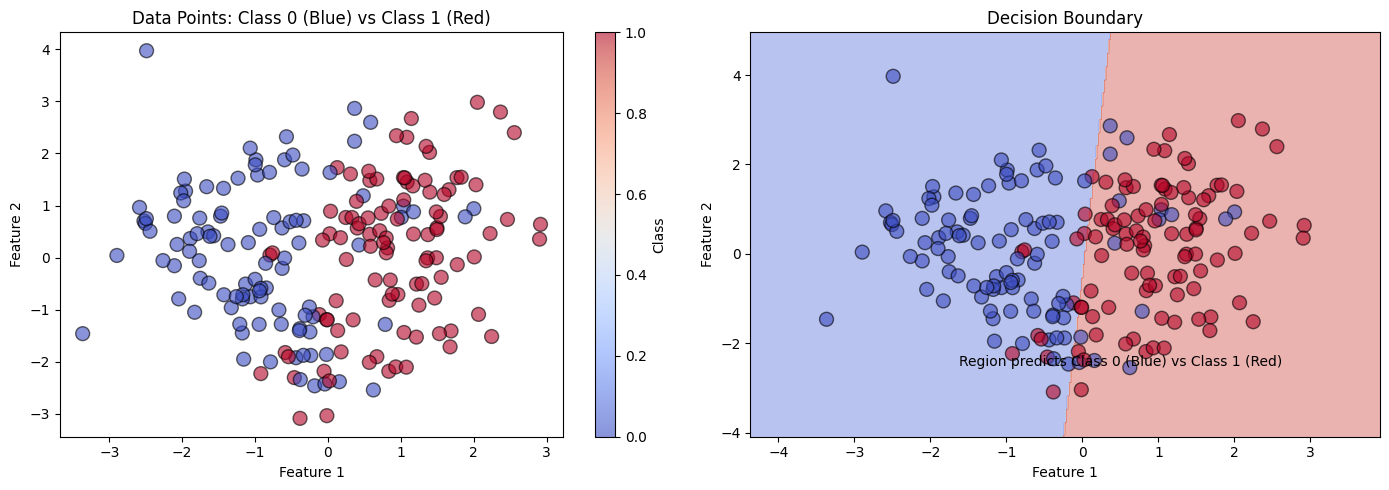

Binary Classification Example:
Training set: 140 samples
Test set: 60 samples
Classes: 0 (Negative) and 1 (Positive)
Model accuracy on test set: 83.3%


In [16]:
import numpy as np
import matplotlib.pyplot as plt
from sklearn.datasets import make_classification
from sklearn.linear_model import LogisticRegression
from sklearn.model_selection import train_test_split

# Create a simple binary classification dataset
np.random.seed(42)
X, y = make_classification(n_samples=200, n_features=2, n_redundant=0,
                           n_informative=2, random_state=42)

# Split data
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.3, random_state=42)

# Train a simple model
model = LogisticRegression()
model.fit(X_train, y_train)

# Plot the results
fig, axes = plt.subplots(1, 2, figsize=(14, 5))

# Plot 1: Data points
ax = axes[0]
scatter = ax.scatter(X[:, 0], X[:, 1], c=y, cmap='coolwarm', s=100, alpha=0.6, edgecolors='black')
ax.set_xlabel('Feature 1')
ax.set_ylabel('Feature 2')
ax.set_title('Binary Classification Dataset')
ax.set_title('Data Points: Class 0 (Blue) vs Class 1 (Red)')
plt.colorbar(scatter, ax=ax, label='Class')

# Plot 2: Decision boundary
ax = axes[1]

# Create mesh
h = 0.02
x_min, x_max = X[:, 0].min() - 1, X[:, 0].max() + 1
y_min, y_max = X[:, 1].min() - 1, X[:, 1].max() + 1
xx, yy = np.meshgrid(np.arange(x_min, x_max, h), np.arange(y_min, y_max, h))

# Predict on mesh
Z = model.predict(np.c_[xx.ravel(), yy.ravel()])
Z = Z.reshape(xx.shape)

# Plot decision boundary
ax.contourf(xx, yy, Z, alpha=0.4, cmap='coolwarm')
ax.scatter(X[:, 0], X[:, 1], c=y, cmap='coolwarm', s=100, alpha=0.6, edgecolors='black')
ax.set_xlabel('Feature 1')
ax.set_ylabel('Feature 2')
ax.set_title('Decision Boundary')
ax.text(0.5, -2.5, 'Region predicts Class 0 (Blue) vs Class 1 (Red)', ha='center')

plt.tight_layout()
plt.show()

print("Binary Classification Example:")
print(f"Training set: {len(X_train)} samples")
print(f"Test set: {len(X_test)} samples")
print(f"Classes: 0 (Negative) and 1 (Positive)")
print(f"Model accuracy on test set: {model.score(X_test, y_test):.1%}")

### Steps in Binary Classification:

1. **Data Collection**: Gather examples with known outcomes
2. **Feature Extraction**: Convert data into numeric features
3. **Train/Test Split**: Divide data for training and evaluation
4. **Model Training**: Fit model to training data
5. **Prediction**: Generate predictions for new data
6. **Evaluation**: Measure model performance (next section!)

In [18]:
# Make predictions on test set
y_pred = model.predict(X_test)

print("\n" + "="*60)
print("BINARY CLASSIFICATION: PREDICTIONS")
print("="*60)

print(f"\nFirst 20 predictions:")
print(f"Actual:    {y_test[:20]}")
print(f"Predicted: {y_pred[:20]}")
print(f"Match:     {['✓' if a == p else '✗' for a, p in zip(y_test[:20], y_pred[:20])]}")


BINARY CLASSIFICATION: PREDICTIONS

First 20 predictions:
Actual:    [1 0 1 1 1 1 1 1 1 0 0 0 1 0 1 1 0 1 0 1]
Predicted: [1 1 1 1 0 1 1 0 1 0 0 0 1 0 1 1 0 1 0 1]
Match:     ['✓', '✗', '✓', '✓', '✗', '✓', '✓', '✗', '✓', '✓', '✓', '✓', '✓', '✓', '✓', '✓', '✓', '✓', '✓', '✓']


# PART 2: CLASSIFICATION METRICS

### What is a Confusion Matrix?

A table that shows all four types of prediction outcomes:

| | **Predicted: Negative (0)** | **Predicted: Positive (1)** |
|---|---|---|
| **Actually: Negative (0)** | True Negative (TN) | False Positive (FP) |
| **Actually: Positive (1)** | False Negative (FN) | True Positive (TP) |

### The Four Outcomes:

- **TP (True Positive)**: Model predicted 1, actually 1 ✓ Correct
- **TN (True Negative)**: Model predicted 0, actually 0 ✓ Correct
- **FP (False Positive)**: Model predicted 1, actually 0 ✗ Wrong (Type I Error)
- **FN (False Negative)**: Model predicted 0, actually 1 ✗ Wrong (Type II Error)

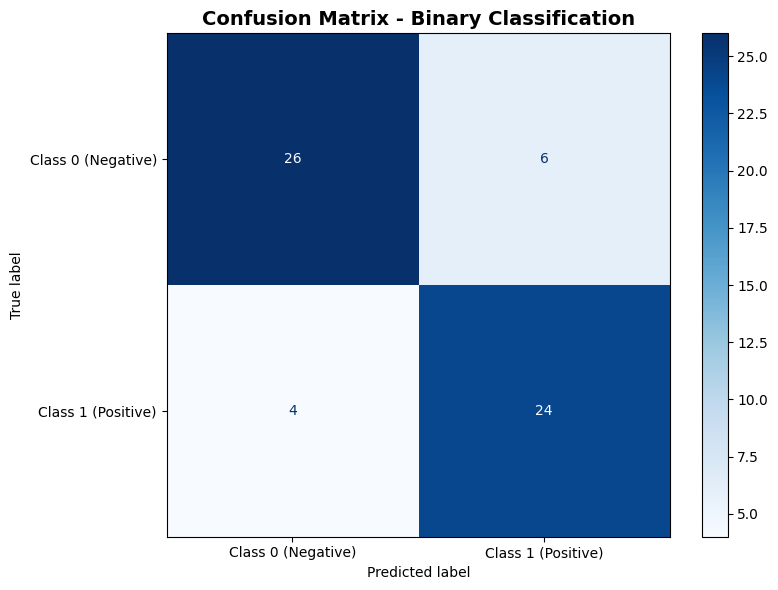


CONFUSION MATRIX BREAKDOWN

True Negatives (TN):   26  (correctly predicted 0)
False Positives (FP):  6  (predicted 1, actually 0) - Type I Error
False Negatives (FN):  4  (predicted 0, actually 1) - Type II Error
True Positives (TP):   24  (correctly predicted 1)

Total Predictions:     60


In [19]:
from sklearn.metrics import confusion_matrix, ConfusionMatrixDisplay
import matplotlib.pyplot as plt

# Calculate confusion matrix
cm = confusion_matrix(y_test, y_pred)

# Display it
fig, ax = plt.subplots(figsize=(8, 6))
disp = ConfusionMatrixDisplay(confusion_matrix=cm, display_labels=['Class 0 (Negative)', 'Class 1 (Positive)'])
disp.plot(ax=ax, cmap='Blues')
ax.set_title('Confusion Matrix - Binary Classification', fontsize=14, fontweight='bold')
plt.tight_layout()
plt.show()

# Extract values
TN = cm[0, 0]
FP = cm[0, 1]
FN = cm[1, 0]
TP = cm[1, 1]

print("\n" + "="*60)
print("CONFUSION MATRIX BREAKDOWN")
print("="*60)
print(f"\nTrue Negatives (TN):   {TN}  (correctly predicted 0)")
print(f"False Positives (FP):  {FP}  (predicted 1, actually 0) - Type I Error")
print(f"False Negatives (FN):  {FN}  (predicted 0, actually 1) - Type II Error")
print(f"True Positives (TP):   {TP}  (correctly predicted 1)")
print(f"\nTotal Predictions:     {TN + FP + FN + TP}")

## Six Important Classification Metrics



### 1. Accuracy

$$\text{Accuracy} = \frac{TP + TN}{TP + TN + FP + FN}$$

**Meaning**: What percentage of predictions were correct?

**When to use**: Balanced datasets

**When NOT to use**: Imbalanced datasets (can be misleading)

In [20]:
from sklearn.metrics import accuracy_score

accuracy = accuracy_score(y_test, y_pred)

print(f"\n{'='*60}")
print(f"METRIC 1: ACCURACY")
print(f"{'='*60}")
print(f"\nFormula: (TP + TN) / Total")
print(f"Calculation: ({TP} + {TN}) / {TN + FP + FN + TP}")
print(f"Accuracy: {accuracy:.1%}")
print(f"\nInterpretation: The model got {accuracy:.0%} of predictions correct.")


METRIC 1: ACCURACY

Formula: (TP + TN) / Total
Calculation: (24 + 26) / 60
Accuracy: 83.3%

Interpretation: The model got 83% of predictions correct.


### 2. Precision

$$\text{Precision} = \frac{TP}{TP + FP}$$

**Meaning**: Of all positive predictions, how many were correct?

**Question**: "When the model says YES, how often is it right?"

**When to use**:
- Spam detection (false positives = blocking good emails)
- Fraud detection (false positives = blocking good transactions)

In [21]:
from sklearn.metrics import precision_score

precision = precision_score(y_test, y_pred)

print(f"\n{'='*60}")
print(f"METRIC 2: PRECISION")
print(f"{'='*60}")
print(f"\nFormula: TP / (TP + FP)")
print(f"Calculation: {TP} / ({TP} + {FP})")
print(f"Precision: {precision:.1%}")
print(f"\nInterpretation:")
print(f"When the model predicts 'Positive' (1), it is correct {precision:.0%} of the time.")
print(f"Out of {TP + FP} positive predictions:")
print(f"  - {TP} were actually positive ✓")
print(f"  - {FP} were actually negative ✗ (false alarms)")


METRIC 2: PRECISION

Formula: TP / (TP + FP)
Calculation: 24 / (24 + 6)
Precision: 80.0%

Interpretation:
When the model predicts 'Positive' (1), it is correct 80% of the time.
Out of 30 positive predictions:
  - 24 were actually positive ✓
  - 6 were actually negative ✗ (false alarms)


### 3. Recall (Sensitivity)

$$\text{Recall} = \frac{TP}{TP + FN}$$

**Meaning**: Of all actual positives, how many did we catch?

**Question**: "Of all the YES cases out there, how many did I find?"

**When to use**:
- Medical diagnosis (missing disease is dangerous)
- Cancer detection (false negatives are life-threatening)

In [22]:
from sklearn.metrics import recall_score

recall = recall_score(y_test, y_pred)

print(f"\n{'='*60}")
print(f"METRIC 3: RECALL (SENSITIVITY)")
print(f"{'='*60}")
print(f"\nFormula: TP / (TP + FN)")
print(f"Calculation: {TP} / ({TP} + {FN})")
print(f"Recall: {recall:.1%}")
print(f"\nInterpretation:")
print(f"The model catches {recall:.0%} of all actual positive cases.")
print(f"Out of {TP + FN} actual positive instances:")
print(f"  - {TP} were correctly identified ✓")
print(f"  - {FN} were missed ✗ (false negatives)")


METRIC 3: RECALL (SENSITIVITY)

Formula: TP / (TP + FN)
Calculation: 24 / (24 + 4)
Recall: 85.7%

Interpretation:
The model catches 86% of all actual positive cases.
Out of 28 actual positive instances:
  - 24 were correctly identified ✓
  - 4 were missed ✗ (false negatives)


### 4. Specificity

$$\text{Specificity} = \frac{TN}{TN + FP}$$

**Meaning**: Of all actual negatives, how many did we correctly identify?

**Question**: "Of all the NO cases out there, how many did I correctly identify as NO?"

**When to use**: When false positives are costly

In [23]:
specificity = TN / (TN + FP)

print(f"\n{'='*60}")
print(f"METRIC 4: SPECIFICITY")
print(f"{'='*60}")
print(f"\nFormula: TN / (TN + FP)")
print(f"Calculation: {TN} / ({TN} + {FP})")
print(f"Specificity: {specificity:.1%}")
print(f"\nInterpretation:")
print(f"The model correctly identifies {specificity:.0%} of actual negative cases.")
print(f"Out of {TN + FP} actual negative instances:")
print(f"  - {TN} were correctly identified as negative ✓")
print(f"  - {FP} were wrongly marked as positive ✗")


METRIC 4: SPECIFICITY

Formula: TN / (TN + FP)
Calculation: 26 / (26 + 6)
Specificity: 81.2%

Interpretation:
The model correctly identifies 81% of actual negative cases.
Out of 32 actual negative instances:
  - 26 were correctly identified as negative ✓
  - 6 were wrongly marked as positive ✗


### 5. F1-Score

$$\text{F1-Score} = 2 \times \frac{\text{Precision} \times \text{Recall}}{\text{Precision} + \text{Recall}}$$

**Meaning**: Harmonic mean of precision and recall

**Why?**: Balances precision and recall. Good for imbalanced datasets.

**When to use**:
- Imbalanced datasets
- When both false positives AND false negatives matter

In [24]:
from sklearn.metrics import f1_score

f1 = f1_score(y_test, y_pred)

print(f"\n{'='*60}")
print(f"METRIC 5: F1-SCORE")
print(f"{'='*60}")
print(f"\nFormula: 2 × (Precision × Recall) / (Precision + Recall)")
print(f"Calculation: 2 × ({precision:.3f} × {recall:.3f}) / ({precision:.3f} + {recall:.3f})")
print(f"F1-Score: {f1:.1%}")
print(f"\nInterpretation:")
print(f"F1-Score balances both precision and recall.")
print(f"Useful when both false positives and false negatives are important.")


METRIC 5: F1-SCORE

Formula: 2 × (Precision × Recall) / (Precision + Recall)
Calculation: 2 × (0.800 × 0.857) / (0.800 + 0.857)
F1-Score: 82.8%

Interpretation:
F1-Score balances both precision and recall.
Useful when both false positives and false negatives are important.


### 6. Type I & Type II Errors

**Type I Error (False Positive)**
$$\text{Type I Error Rate} = \frac{FP}{FP + TN}$$
- Model says YES, but actually NO
- False alarm

**Type II Error (False Negative)**
$$\text{Type II Error Rate} = \frac{FN}{TP + FN}$$
- Model says NO, but actually YES
- Missed case

In [25]:
type1_error_rate = FP / (FP + TN) if (FP + TN) > 0 else 0
type2_error_rate = FN / (TP + FN) if (TP + FN) > 0 else 0

print(f"\n{'='*60}")
print(f"METRIC 6: TYPE I & TYPE II ERRORS")
print(f"{'='*60}")

print(f"\nType I Error (False Positive Rate):")
print(f"Formula: FP / (FP + TN) = {FP} / ({FP} + {TN}) = {type1_error_rate:.1%}")
print(f"Interpretation: {type1_error_rate:.0%} of actual negatives are wrongly predicted as positive.")

print(f"\nType II Error (False Negative Rate):")
print(f"Formula: FN / (TP + FN) = {FN} / ({TP} + {FN}) = {type2_error_rate:.1%}")
print(f"Interpretation: {type2_error_rate:.0%} of actual positives are wrongly predicted as negative.")


METRIC 6: TYPE I & TYPE II ERRORS

Type I Error (False Positive Rate):
Formula: FP / (FP + TN) = 6 / (6 + 26) = 18.8%
Interpretation: 19% of actual negatives are wrongly predicted as positive.

Type II Error (False Negative Rate):
Formula: FN / (TP + FN) = 4 / (24 + 4) = 14.3%
Interpretation: 14% of actual positives are wrongly predicted as negative.
